In [3]:
import requests
url = "https://www.scrapethissite.com/pages/forms/"
html = requests.get(url)
with open("hockey_data.txt","w",encoding = "utf-8") as file:
    file.write(html.text)
    print("Find Readed")

Find Readed


In [16]:
from bs4 import BeautifulSoup
import pandas as pd

with open("hockey_data.txt","r",encoding = "utf-8") as file:
    html = file.read()

name_list = []
year_list = []
win_list = []
looses_list = []

soup = BeautifulSoup(html,"html.parser")
teams = soup.find_all(class_="team")
for team in teams:
    name = team.find(class_="name").text.strip()
    year = team.find(class_="year").text.strip()
    win = team.find(class_="wins").text.strip()
    loose = team.find(class_="losses").text.strip()
    
    name_list.append(name)
    year_list.append(year)
    win_list.append(win)
    looses_list.append(loose)

df = pd.DataFrame({"Name" : name_list,
                  "Year":year_list,
                  "Win":win_list,
                   "Loose":looses_list})
print(df)

                     Name  Year Win Loose
0           Boston Bruins  1990  44    24
1          Buffalo Sabres  1990  31    30
2          Calgary Flames  1990  46    26
3      Chicago Blackhawks  1990  49    23
4       Detroit Red Wings  1990  34    38
5         Edmonton Oilers  1990  37    37
6        Hartford Whalers  1990  31    38
7       Los Angeles Kings  1990  46    24
8   Minnesota North Stars  1990  27    39
9      Montreal Canadiens  1990  39    30
10      New Jersey Devils  1990  32    33
11     New York Islanders  1990  25    45
12       New York Rangers  1990  36    31
13    Philadelphia Flyers  1990  33    37
14    Pittsburgh Penguins  1990  41    33
15       Quebec Nordiques  1990  16    50
16        St. Louis Blues  1990  47    22
17    Toronto Maple Leafs  1990  23    46
18      Vancouver Canucks  1990  28    43
19    Washington Capitals  1990  37    36
20          Winnipeg Jets  1990  26    43
21          Boston Bruins  1991  36    32
22         Buffalo Sabres  1991  3

In [21]:
import requests

for i in range(1, 25):

    html = requests.get(
        f"https://www.scrapethissite.com/pages/forms/?page_num={i}"
    )

    with open(
        f"hockey_data/data{i}.txt",
        "w",
        encoding="utf-8"
    ) as file:

        file.write(html.text)

print("All pages saved")

All pages saved


In [164]:
from bs4 import BeautifulSoup
import pandas as pd

# Empty lists OUTSIDE loop
name_list = []
year_list = []
win_list = []
looses_list = []

for i in range(1, 25):

    with open(
        f"hockey_data/data{i}.txt",
        "r",
        encoding="utf-8"
    ) as file:

        html = file.read()

    soup = BeautifulSoup(html, "html.parser")

    teams = soup.find_all(class_="team")

    for team in teams:

        name = team.find(class_="name").text.strip()

        year = team.find(class_="year").text.strip()

        win = team.find(class_="wins").text.strip()

        loose = team.find(class_="losses").text.strip()

        # Append data
        name_list.append(name)
        year_list.append(int(year))
        win_list.append(int(win))
        looses_list.append(int(loose))

# Create DataFrame AFTER all pages
df = pd.DataFrame({
    "Name": name_list,
    "Year": year_list,
    "Win": win_list,
    "Loose": looses_list
})

# Save CSV
df.to_csv("Hockey.csv", index=False)

print(df)

                    Name  Year  Win  Loose
0          Boston Bruins  1990   44     24
1         Buffalo Sabres  1990   31     30
2         Calgary Flames  1990   46     26
3     Chicago Blackhawks  1990   49     23
4      Detroit Red Wings  1990   34     38
..                   ...   ...  ...    ...
577  Tampa Bay Lightning  2011   38     36
578  Toronto Maple Leafs  2011   35     37
579    Vancouver Canucks  2011   51     22
580  Washington Capitals  2011   42     32
581        Winnipeg Jets  2011   37     35

[582 rows x 4 columns]


In [13]:
# Find the team with maximum wins.
df[df["Win"] == df["Win"].max()]

,Name,Year,Win,Loose
126,Detroit Red Wings,1995,62,13


In [14]:
# Find the team with minimum losses.
df[df["Loose"] == df["Loose"].min()]

,Name,Year,Win,Loose
99,Detroit Red Wings,1994,33,11


In [15]:
# Find all teams having wins greater than 40.
df[df["Win"]>40]

,Name,Year,Win,Loose
0,Boston Bruins,1990,44,24
2,Calgary Flames,1990,46,26
3,Chicago Blackhawks,1990,49,23
7,Los Angeles Kings,1990,46,24
14,Pittsburgh Penguins,1990,41,33
...,...,...,...,...
574,Pittsburgh Penguins,2011,51,25
575,San Jose Sharks,2011,43,29
576,St. Louis Blues,2011,49,22
579,Vancouver Canucks,2011,51,22


In [74]:
df[df["Loose"]<20]

,Name,Year,Win,Loose
94,Boston Bruins,1994,27,18
95,Buffalo Sabres,1994,22,19
96,Calgary Flames,1994,24,17
97,Chicago Blackhawks,1994,24,19
99,Detroit Red Wings,1994,33,11
105,New Jersey Devils,1994,22,18
109,Philadelphia Flyers,1994,28,16
110,Pittsburgh Penguins,1994,29,16
111,Quebec Nordiques,1994,30,13
113,St. Louis Blues,1994,28,15


In [17]:
# Find average wins of all teams.
df["Win"].mean()

np.float64(36.94329896907217)

In [78]:
# Find average losses of all teams.
df["Loose"].mean()

np.float64(32.35395189003437)

In [85]:
# Find top 10 teams with highest wins.
df.sort_values("Win",ascending=False).head(10)

,Name,Year,Win,Loose
126,Detroit Red Wings,1995,62,13
382,Detroit Red Wings,2005,58,16
58,Pittsburgh Penguins,1992,56,21
521,Washington Capitals,2009,54,15
550,Vancouver Canucks,2010,54,19
442,Detroit Red Wings,2007,54,21
464,Boston Bruins,2008,53,19
486,San Jose Sharks,2008,53,18
405,Buffalo Sabres,2006,53,22
381,Dallas Stars,2005,53,23


In [86]:
# Find bottom 10 teams with lowest wins.
df.sort_values("Win",ascending=False).tail(10)

,Name,Year,Win,Loose
103,Los Angeles Kings,1994,16,23
15,Quebec Nordiques,1990,16,50
93,Mighty Ducks of Anaheim,1994,16,27
118,Winnipeg Jets,1994,16,25
106,New York Islanders,1994,15,28
225,Atlanta Thrashers,1999,14,57
82,Ottawa Senators,1993,14,61
60,San Jose Sharks,1992,11,71
56,Ottawa Senators,1992,10,70
108,Ottawa Senators,1994,9,34


In [88]:
# Sort teams by wins in descending order.
df.sort_values("Win",ascending=True)

,Name,Year,Win,Loose
108,Ottawa Senators,1994,9,34
56,Ottawa Senators,1992,10,70
60,San Jose Sharks,1992,11,71
82,Ottawa Senators,1993,14,61
225,Atlanta Thrashers,1999,14,57
...,...,...,...,...
521,Washington Capitals,2009,54,15
550,Vancouver Canucks,2010,54,19
58,Pittsburgh Penguins,1992,56,21
382,Detroit Red Wings,2005,58,16


In [19]:
# Find all teams from year 2011.
df[df["Year"]>=2011]

,Name,Year,Win,Loose
552,Anaheim Ducks,2011,34,36
553,Boston Bruins,2011,49,29
554,Buffalo Sabres,2011,39,32
555,Calgary Flames,2011,37,29
556,Carolina Hurricanes,2011,33,33
557,Columbus Blue Jackets,2011,29,46
558,Chicago Blackhawks,2011,45,26
559,Colorado Avalanche,2011,41,35
560,Dallas Stars,2011,42,35
561,Detroit Red Wings,2011,48,28


In [114]:
# Find all teams between years 2005 and 2010.
df[(df["Year"]>=2005) & (df["Year"]<=2010)]
df[df["Year"].between(2005,2010)]

,Name,Year,Win,Loose
372,Mighty Ducks of Anaheim,2005,43,27
373,Atlanta Thrashers,2005,41,33
374,Boston Bruins,2005,29,37
375,Buffalo Sabres,2005,52,24
376,Calgary Flames,2005,46,25
...,...,...,...,...
547,St. Louis Blues,2010,38,33
548,Tampa Bay Lightning,2010,46,25
549,Toronto Maple Leafs,2010,37,34
550,Vancouver Canucks,2010,54,19


In [141]:
# Count total unique teams.
df["Name"].unique()

<StringArray>
[          'Boston Bruins',          'Buffalo Sabres',
          'Calgary Flames',      'Chicago Blackhawks',
       'Detroit Red Wings',         'Edmonton Oilers',
        'Hartford Whalers',       'Los Angeles Kings',
   'Minnesota North Stars',      'Montreal Canadiens',
       'New Jersey Devils',      'New York Islanders',
        'New York Rangers',     'Philadelphia Flyers',
     'Pittsburgh Penguins',        'Quebec Nordiques',
         'St. Louis Blues',     'Toronto Maple Leafs',
       'Vancouver Canucks',     'Washington Capitals',
           'Winnipeg Jets',         'San Jose Sharks',
         'Ottawa Senators',     'Tampa Bay Lightning',
 'Mighty Ducks of Anaheim',            'Dallas Stars',
        'Florida Panthers',      'Colorado Avalanche',
         'Phoenix Coyotes',     'Carolina Hurricanes',
     'Nashville Predators',       'Atlanta Thrashers',
   'Columbus Blue Jackets',          'Minnesota Wild',
           'Anaheim Ducks']
Length: 35, dtype: str

In [129]:
# Find how many records each year contains.
df["Year"].value_counts().sort_index()

Year
1990    21
1991    22
1992    24
1993    26
1994    26
1995    26
1996    26
1997    26
1998    27
1999    28
2000    30
2001    30
2002    30
2003    30
2005    30
2006    30
2007    30
2008    30
2009    30
2010    30
2011    30
Name: count, dtype: int64

In [139]:
# Find which year has highest average wins.
df.groupby("Year")["Win"].mean().sort_values(ascending=False).head(1)

Year
2006    41.0
Name: Win, dtype: float64

In [167]:
# Find which year has lowest average losses.
df.groupby("Year")["Win"].mean().sort_values(ascending=False).tail(1)

Year
1994    21.115385
Name: Win, dtype: float64

In [26]:
"""17. Create a new column:

```python id="m4u8tp"
Win_Difference = Wins - Losses
```"""
df["Win_Difference"] = df["Win"] - df["Loose"]

In [175]:
# Find team with highest win difference.
df[df["Win_Difference"] == df["Win_Difference"].max()]

,Name,Year,Win,Loose,Win_Difference,Win_Difference
126,Detroit Red Wings,1995,62,13,49,49


In [179]:
 # Find team with lowest win difference.
df[df["Win_Difference"] == df["Win_Difference"].min()]

,Name,Year,Win,Loose,Win_Difference,Win_Difference
56,Ottawa Senators,1992,10,70,-60,-60
60,San Jose Sharks,1992,11,71,-60,-60


In [180]:
# Find correlation between wins and losses.
df["Win"].corr(df["Loose"])

np.float64(-0.6684289644268735)

In [31]:
# Plot bar chart of top 10 teams by wins.
top_team = df.sort_values("Win", ascending=False).head(10)

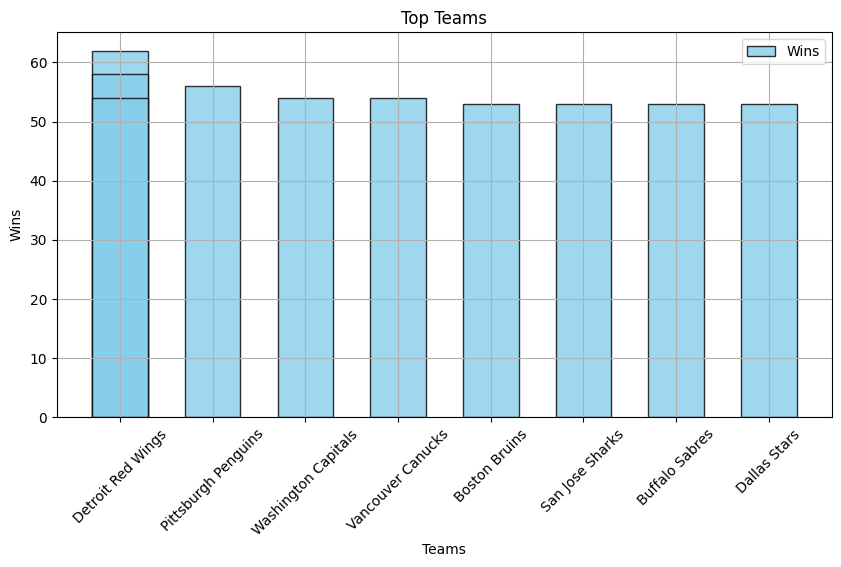

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.bar(
    top_team["Name"],
    top_team["Win"],
    color="skyblue",
    edgecolor="black",
    linewidth=1,
    width=0.6,
    alpha=0.8,
    label="Wins"
)

plt.xlabel("Teams")
plt.ylabel("Wins")
plt.title("Top Teams")

plt.xticks(rotation=45)

plt.grid(True)

plt.legend()

plt.show()

In [33]:
# Plot histogram of wins.
wins = df["Win"]

Text(0.5, 1.0, 'Histogram of Wins')

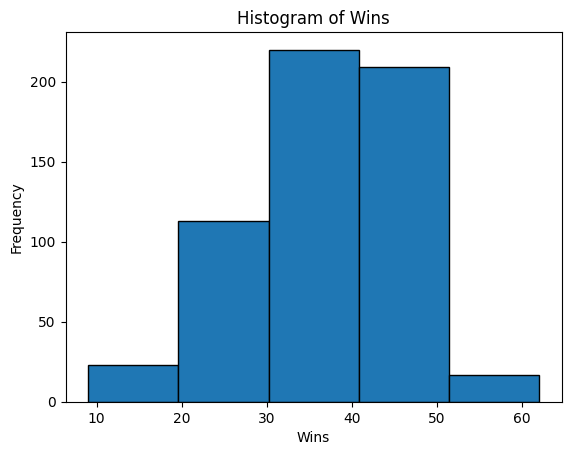

In [38]:
plt.hist(wins,bins=5,edgecolor="black")
plt.xlabel("Wins")
plt.ylabel("Frequency")
plt.title("Histogram of Wins")

Text(0.5, 1.0, 'Histogram of Loose')

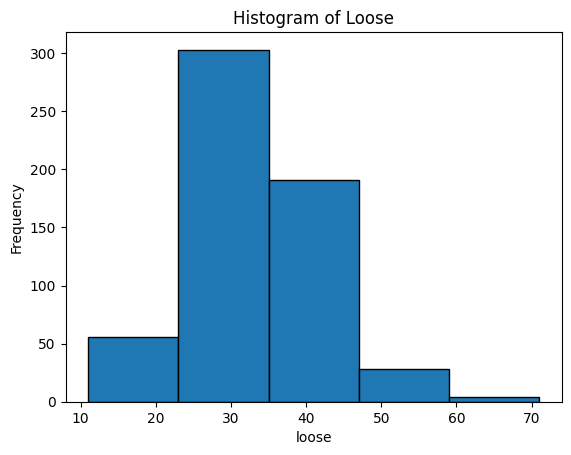

In [40]:
# Plot histogram of losses.
loose = df["Loose"]
plt.hist(loose,bins=5,edgecolor="black")
plt.xlabel("loose")
plt.ylabel("Frequency")
plt.title("Histogram of Loose")

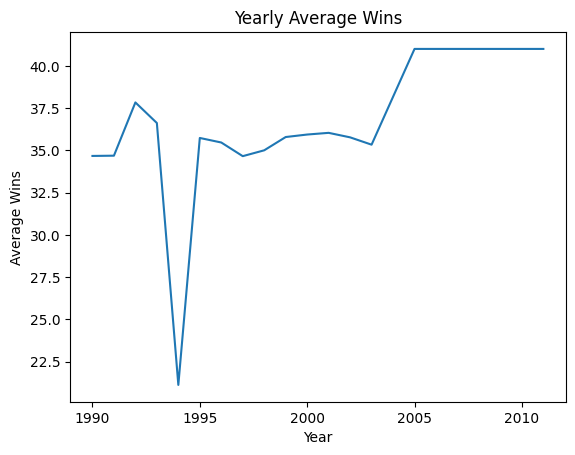

In [50]:
# Plot line graph of yearly average wins.

avg_win = df.groupby("Year")["Win"].mean()

# Line graph
plt.plot(avg_win.index, avg_win.values)

plt.xlabel("Year")
plt.ylabel("Average Wins")
plt.title("Yearly Average Wins")

plt.show()

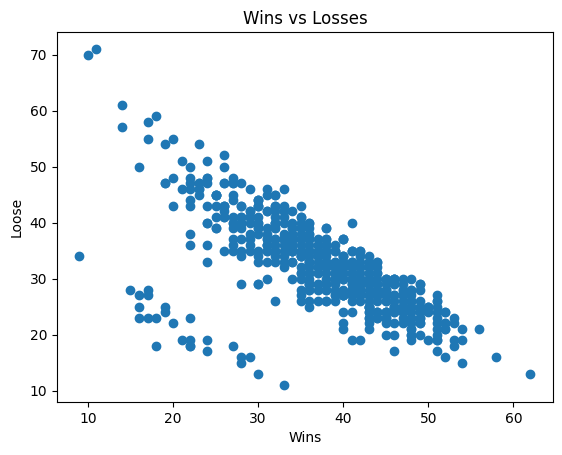

In [51]:
# Plot scatter graph of wins vs losses.

# Scatter plot
plt.scatter(df["Win"], df["Loose"])

plt.xlabel("Wins")
plt.ylabel("Loose")
plt.title("Wins vs Losses")

plt.show()

In [57]:
# Find teams whose wins are above average.
df[df["Win"] > df["Win"].mean()]

,Name,Year,Win,Loose,Win_Difference
0,Boston Bruins,1990,44,24,20
2,Calgary Flames,1990,46,26,20
3,Chicago Blackhawks,1990,49,23,26
5,Edmonton Oilers,1990,37,37,0
7,Los Angeles Kings,1990,46,24,22
...,...,...,...,...,...
576,St. Louis Blues,2011,49,22,27
577,Tampa Bay Lightning,2011,38,36,2
579,Vancouver Canucks,2011,51,22,29
580,Washington Capitals,2011,42,32,10


In [59]:
# Find teams whose losses are below average.
df[df["Loose"]<df["Loose"].mean()]

,Name,Year,Win,Loose,Win_Difference
0,Boston Bruins,1990,44,24,20
1,Buffalo Sabres,1990,31,30,1
2,Calgary Flames,1990,46,26,20
3,Chicago Blackhawks,1990,49,23,26
7,Los Angeles Kings,1990,46,24,22
...,...,...,...,...,...
574,Pittsburgh Penguins,2011,51,25,26
575,San Jose Sharks,2011,43,29,14
576,St. Louis Blues,2011,49,22,27
579,Vancouver Canucks,2011,51,22,29


In [60]:
# Find median wins.
df["Win"].median()

np.float64(38.0)

In [62]:
# Find mode of wins.
df["Win"].mode()

0    43
Name: Win, dtype: int64

In [64]:
# Standard deviation of wins

std_win = df["Win"].std()
print(std_win)

8.92608092028576


In [67]:
 # Find all teams with exactly 50 wins.
df[df["Win"]==50]

,Name,Year,Win,Loose,Win_Difference
33,New York Rangers,1991,50,25,25
411,Dallas Stars,2006,50,25,25
412,Detroit Red Wings,2006,50,19,31
491,Washington Capitals,2008,50,24,26
514,Phoenix Coyotes,2009,50,25,25


In [86]:
# Find all years where average wins exceeded 35.
avg_win = df.groupby("Year")["Win"].mean()

avg_win[avg_win > 35]

Year
1992    37.833333
1993    36.615385
1995    35.730769
1996    35.461538
1999    35.785714
2000    35.933333
2001    36.033333
2002    35.766667
2003    35.333333
2005    41.000000
2006    41.000000
2007    41.000000
2008    41.000000
2009    41.000000
2010    41.000000
2011    41.000000
Name: Win, dtype: float64

In [91]:
# Find duplicate team names if any.
df[df.duplicated(["Name"])]


,Name,Year,Win,Loose,Win_Difference
21,Boston Bruins,1991,36,32,4
22,Buffalo Sabres,1991,31,37,-6
23,Calgary Flames,1991,31,37,-6
24,Chicago Blackhawks,1991,36,29,7
25,Detroit Red Wings,1991,43,25,18
...,...,...,...,...,...
577,Tampa Bay Lightning,2011,38,36,2
578,Toronto Maple Leafs,2011,35,37,-2
579,Vancouver Canucks,2011,51,22,29
580,Washington Capitals,2011,42,32,10


In [95]:
df.drop_duplicates(["Name"])

,Name,Year,Win,Loose,Win_Difference
0,Boston Bruins,1990,44,24,20
1,Buffalo Sabres,1990,31,30,1
2,Calgary Flames,1990,46,26,20
3,Chicago Blackhawks,1990,49,23,26
4,Detroit Red Wings,1990,34,38,-4
5,Edmonton Oilers,1990,37,37,0
6,Hartford Whalers,1990,31,38,-7
7,Los Angeles Kings,1990,46,24,22
8,Minnesota North Stars,1990,27,39,-12
9,Montreal Canadiens,1990,39,30,9


In [101]:
# Find the latest year in dataset.
df.sort_values("Year",ascending=False).head(1)

,Name,Year,Win,Loose,Win_Difference
563,Florida Panthers,2011,38,26,12


In [102]:
# Find the oldest year in dataset.
df.sort_values("Year",ascending=True).head(1)

,Name,Year,Win,Loose,Win_Difference
0,Boston Bruins,1990,44,24,20


In [104]:
# Find total wins of all teams combined.
df["Win"].sum()

np.int64(21501)

In [106]:
# Find total losses of all teams combined.
df["Loose"].sum()

np.int64(18830)

In [117]:
# Find percentage of teams having wins above 30.
total_teams = len(df)
teams_above_30 = len(df[df["Win"] > 30])
percentage = (teams_above_30 / total_teams) * 100
print(percentage)

76.6323024054983


In [118]:
# Filter top teams
top_teams = df[df["Win"] > 30]

# Save into CSV
top_teams.to_csv("top_teams.csv", index=False)

print("CSV file saved successfully")

CSV file saved successfully
